---
tags: [algorithm, finance, variational]
---

# 深さ効率の良い量子トポロジカルデータ解析

金融市場のダイナミクスは非線形であり、古典的な統計手法ではその全容を十分に捉えることができません。
トポロジカルデータ解析 (TDA) が提案され、データ点群からデータのトポロジーを抽出する効率的な手法が提供されました。
しかし、その中心的な不変量であるベッチ数の計算にはコスト増加が伴うため、大規模な計算には不向きでした。
この計算のボトルネックに対処するために考案された量子 TDA (qTDA) には、多数の量子ビットと深い回路が必要であり、こちらも現実的ではありません。
そこで本記事では、深さ効率の良い qTDA を提案した [Mazumder & Mazumder (2026)](https://arxiv.org/abs/2607.09906) について解説し、それの Qamomile での実装例を示しました。

In [1]:
# Install the latest Qamomile through pip! 
# !pip install qamomile

In [2]:
import numpy as np
from itertools import combinations, product
from math import comb
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm.basic import cx_entangling_layer, ry_layer, rz_layer
from qamomile.qiskit import QiskitTranspiler

## 背景

### 問題: トポロジカルデータ解析と金融工学

金融市場の動向を予測することの重要性は、ますます大きくなっています。
その計算を行うための統計手法が様々考案されてきましたが、大きな金融危機には対応できていないのが現状です。
2008年のリーマン・ショックは、分散や VaR などのボラティリティ指標では捉えられなかった相関関係と構造的な不安定性から生じたとされています。
[Gidea & Katz (2018)](https://www.sciencedirect.com/science/article/abs/pii/S0378437117309202?via%3Dihub) では、データ点群のパーシステンス (データ点群が作る穴の寿命・持続度) をベースとしたトポロジカルな特徴量が、リーマン・ブラザーズの経営破綻の250日前から強い上昇傾向にあることを示しました。
すなわち、従来手法では予測できなかった未曾有の金融危機を、トポロジカルデータ解析 (TDA) ならば予測できる可能性を見出したのです。
トポロジカルデータ解析では、データ点が作る多様体における $k$ 次元の穴の数を数えます。
$\beta_0, \beta_1, \beta_2$ などはそれぞれ連結成分・ループ数・穴の数に対応します。
$k$ 次元の場合には $\beta_k$ まで存在し、これらをベッチ数 (Betti numbers) と呼びます。
この計算には $\mathcal{O} (n_k^3)$ のコストがかかるとされており、古典手法では限界があります ($n_k$: データ点が作る $k$ 次単体の総数)。
これに対処するために、量子 TDA (qTDA) アルゴリズムが提案されてきました。
代表的なものとして、量子位相推定 (QPE) を用い、組合せ (ホッジ) ラプラシアン $\Delta_k$ の固有スペクトルを推定し、そこからベッチ数を復元する方法があります。
しかし QPE は多数の量子ビットと深い回路が必要であり、NISQや初期FTQCでは実装が困難です。

### 先行研究

先ほど説明した QPE を用いたベッチ数推定を行った研究に、[Lloyd et al. (2016)](https://www.nature.com/articles/ncomms10138) があります。
これは、ユニタリ $U = e^{i\Delta_k}$ に QPE を適用することで、ゼロ固有値の数 (すなわちベッチ数) を推定するというものです (以降、この手法を LGZ アルゴリズムと呼ぶことにします)。
しかし、QPE では多数のアンシラ量子ビットが必要となるため、現在の量子コンピュータでは実行できない欠点があります。  
そして [Schmidhuber & Lloyd (2023)](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.4.040349) は、TDA の計算量を詳細に調査した研究です。
LGZ アルゴリズムはその提案以降、古典手法に対し、QPE による指数的な量子優位性を有すると考えられてきました。
しかしこの研究により、ベッチ数の厳密計算は #P 困難であり、さらに近似計算であっても NP 困難であることが示されました。
この結果は、ベッチ数計算の最悪ケースにおいては、量子コンピュータでも多項式的な優位性しか得られないことを意味します。
実際、特殊ケースとして LGZ アルゴリズムを取り上げ、これが二次的な高速化しか達成しないことも示したのです。  
そこで [Mazumder & Mazumder (2026)](https://arxiv.org/abs/2607.09906) では、QPE を用いるのでなく、PEC による手法を新たに探求しました。

### パウリ相関符号化 (PCE)

PCE は [Sciorilli et al. (2025)](https://www.nature.com/articles/s41467-024-55346-z) により提案された、量子ビット効率の良い符号化手法です。
$m$ 個のバイナリ変数 $x_1, x_2, \dots, x_m \in \{-1, 1\}$ を考え、この変数を用いた目的関数 $f(\boldsymbol{x})$ を最小化したいとしましょう。
QAOA などの変分量子アルゴリズムでは 1 変数を表現するのに 1 量子ビットを用いるため、大規模な問題を表現するには多数の量子ビットが必要となります。
これに対し PCE は、より少ない量子ビットで、問題を効率よく表現するのに用いられます。  
$n$ 量子ビットに対し、$k$ 個にだけパウリ演算子 $X, Y, Z$ が作用する演算子を、$k$ 体のパウリ相関関数 (k-body Pauli correlators) と呼びます。
例えば、$n=3, k=2$ の場合

$$
\Pi_1^{(k)}
= Z_1 \otimes Z_2 \otimes I_3, \quad \Pi_2^{(k)} 
= X_1 \otimes I_2 \otimes Y_3 \dots \tag{1}
$$

などが考えられます。
$m$ 個のパウリ文字列 $\Pi^{(k)} = \{\Pi_1^{(k)}, \Pi_2^{(k)}, \dots, \Pi_m^{(k)}\}$ を考え、$n$ 量子ビットのパラメトライズ量子状態 $\vert \Psi (\boldsymbol{\theta}) \rangle$ に対する $\Pi_i^{(k)}$ の期待値を計算しましょう。
すると

$$
c_i 
= \langle \Psi (\boldsymbol{\theta}) \vert \Pi_i^{(k)} \vert \Psi (\boldsymbol{\theta}) \rangle \tag{2}
$$

のようになります。
この $c_i$ の符号、すなわち $\mathrm{sgn} (c_i)$ を考えることで、$i$ 番目のバイナリ変数 $x_i$ を表現するのがパウリ相関符号化です。
先ほどの $k=2$ の例の場合、$n$ 量子ビットのうちの 2 つにのみ $X, Y, Z$ のいずれかを作用させる場合の数は ${}_n C_2 \times 3^2 = \frac{3^2}{2} n (n-1)$ です。
このため、$m = \mathcal{O} (n^2)$ のバイナリ変数を表現可能であることがわかります。
同様に $k=3$ では ${}_n C_3 \times 3^3 = \frac{3^2}{2} n (n-1) (n-2)$ であることから、$m = \mathcal{O} (n^3)$ のバイナリ変数を表現することができます。
バイナリ変数 $x_i$ を連続緩和した $c_i$ を考えることで、その表現能力を向上させたものと見ることもできます。
また [Sciorilli et al. (2025)](https://www.nature.com/articles/s41467-024-55346-z) では、変分量子アルゴリズムでしばしば問題となる不毛のプラトーも、超多項式で抑制されることも示しました。

## アルゴリズム

### ベッチ数と PCE

$k$ 次の鎖を $(k-1)$ 次の鎖にマッピングする境界作用素を $\partial_k: C_k \rightarrow C_{k-1}$ のように書くことにします。
すると $k$ 次の組合せ (ホッジ) ラプラシアンは、次のように定義されます。

$$
\Delta_k 
= \partial_{k+1} \partial_{k+1}^\top + \partial_k^\top \partial_k 
\in \mathbb{R}^{n_k \times n_k} \tag{3}
$$

ここで $n_k = \vert \mathcal{C}_k \vert$ は $k$ 次の単体の数です。
そしてホッジ分解定理より

$$
\beta_k 
= \mathrm{dim} \ \mathrm{ker} (\Delta_k) \tag{4}
$$

のようにして、ベッチ数 $\beta_k$ を求めることができます。
ここで $\mathrm{dim}$ は次元数、そして $\mathrm{ker}$ はカーネルを表します。
すなわち式 (4) は、$\Delta_k \boldsymbol{v} = \mathbf{0}$ を満たすベクトル $\boldsymbol{v}$ が張る空間の次元数がベッチ数に一致することを意味します。
さらにはベッチ数は、ゼロとなる $\Delta_k$ 固有値の数と言い換えることもできます。  
式 (3) より、$\Delta_k$ は $n_k \times n_k$ の実対称行列です。
その零空間基底ベクトル $\boldsymbol{v} \in \mathbb{R}^{n_k}$ の各成分 $v_i$ を、$n$ 量子ビットのパウリ期待値で表現しましょう。
すなわち、式 (2) から $v_i = c_i (\theta) = \langle \Psi (\boldsymbol{\theta}) \vert \Pi_i^{(k)} \vert \Psi (\boldsymbol{\theta}) \rangle$ のようにします。
先ほどの説明では、PCE は最後に $\mathrm{sgn} (c_i)$ のようにバイナリ変数に丸め込みました。
しかし零ベクトルの成分は連続な値であるため、符号のみを考えずに、$c_i (\theta)$ をそのまま固有ベクトルの成分として用います。

### レイリー商の最小化と変分デフレーション

ここまでの議論でベッチ数を求める問題が、$\Delta_k$ の固有値がゼロとなる数を求める問題に帰着することがわかります。
そこで、変分アルゴリズムで最小化する損失関数として、次のレイリー商を考えることにしましょう。

$$
\mathcal{L} (\boldsymbol{\theta}) 
= \frac{\boldsymbol{c}(\boldsymbol{\theta})^\top \Delta_k \boldsymbol{c} (\boldsymbol{\theta})}{\boldsymbol{c} (\boldsymbol{\theta})^\top \boldsymbol{c} (\boldsymbol{\theta})} \tag{5}
$$

ここで $\boldsymbol{c} (\boldsymbol{\theta}) = (c_1(\boldsymbol{\theta}), c_2(\boldsymbol{\theta}), \dots, c_{n_k}(\boldsymbol{\theta}))^\top$ です。
$\Delta_k$ は対称行列であることから、レイリー商の最小値は $\Delta_k$ の固有値の最小値に一致します (レイリー商において成り立つ min-max 定理)。
よって式 (5) を最小化し、$\mathcal{L} = 0$ となる $\boldsymbol{\theta}$ を求めることができれば、零ベクトルを見つけたことになります。  
ベッチ数を計算するには、複数のゼロ固有値を発見する必要があります。
そこで $j$ 番目の零ベクトル $\boldsymbol{c}^{(j)}$ は発見済みであるとして、次の零ベクトル $\boldsymbol{c}^{(j+1)}$ を探索する際には、次のような損失関数を用いることにします。

$$
\mathcal{L}_{j+1} (\boldsymbol{\theta}) 
= \mathcal{L} (\boldsymbol{\theta}) + \mu \sum_{\ell=1}^j \left\vert \frac{\boldsymbol{c} (\boldsymbol{\theta})^\top \boldsymbol{c}^{(\ell)}}{\| \boldsymbol{c} (\boldsymbol{\theta})\| \| \boldsymbol{c}^{(\ell)} \|} \right\vert^2 \tag{6}
$$

ここで $\mu$ はペナルティ項の重みを表す定数です。
この第二項は、すでに見つけた零ベクトル $\boldsymbol{c}^{(j)}$ と直交する方向のベクトルであれば、値がゼロとなるような項です。
これにより、すでに発見された零ベクトル以外の零ベクトルへの収束を促すことができます。
これは量子コンピュータを用いて分子の励起状態を計算する手法である、変分デフレーション ([Higgott et al. (2019)](https://quantum-journal.org/papers/q-2019-07-01-156/)) にヒントを得たものです。

## Qamomile による実装

それでは、実際に Qamomile を用いて PCE-VQE を実装し、トポロジカルデータ解析を行なってみましょう。

### 組合せラプラシアンとその固有値の古典計算

複体の辺のリストと三角形のリストを受け取り、組合せラプラシアン式 (3) を計算する関数を定義しましょう。
$\partial_1$ は各辺の始点を -1・終点を +1 で表す隣接行列であり、$\partial_2$ は各三角形を符号つきの 3 辺で表す行列です。
三角形が存在しない複体では、$\partial_2$ は空となります。

In [3]:
def build_laplacian(n_vertices, edges, triangles):
    """辺リストと三角形リストから組合せラプラシアン Δ₁ を作る"""
    edge_idx = {e: k for k, e in enumerate(edges)}
    n_e = len(edges)
    B1 = np.zeros((n_vertices, n_e))
    for k, (v0, v1) in enumerate(edges):
        B1[v0, k] = -1.0
        B1[v1, k] = +1.0
    B2 = np.zeros((n_e, len(triangles)))
    for t, (v0, v1, v2) in enumerate(triangles):
        for (a, b), sg in [((v1, v2), +1), ((v0, v2), -1), ((v0, v1), +1)]:
            e = (a, b) if a < b else (b, a)
            B2[edge_idx[e], t] = float(sg)
    return B2 @ B2.T + B1.T @ B1

先ほどの関数から計算された組合せラプラシアンを、古典的に解く関数も定義しておきましょう。
組合せラプラシアン $\Delta_1$ を古典的に固有値分解し、ベッチ数 $\beta_1$ とその零空間基底を求めます。
Qamomile を用いた実装による計算において、ウォームスタートするための初期値の準備と、後に Qamomile 計算との比較を行います。

In [4]:
def classical_betti1(L1, tol=1e-9):
    """古典 β₁ = dim ker Δ₁ と零空間基底を返す(正解 & ウォームスタート目標)"""
    ev, evec = np.linalg.eigh(L1)
    mask = np.abs(ev) < tol
    return int(mask.sum()), evec[:, mask]

### PCE の設定

$\Delta_1$ の各辺を符号化するために、パウリ相関符号化で用いるパウリ文字列を作成する関数を準備しましょう。

In [5]:
def build_correlator_observables(n_needed, kappa):
    """n_needed 本の k体 Pauli 相関子を Qamomile Hamiltonian として返す"""
    n_q = max(kappa, 1)
    while comb(n_q, kappa) * (3**kappa) < n_needed:
        n_q += 1
    pauli_fn = {"X": qm_o.X, "Y": qm_o.Y, "Z": qm_o.Z}
    observables = []
    for pos in combinations(range(n_q), kappa):
        for ch in product("XYZ", repeat=kappa):
            H = qm_o.Hamiltonian()
            H.constant = 1.0
            for p, c in zip(pos, ch):
                H *= pauli_fn[c](p)
            observables.append(H)
            if len(observables) == n_needed:
                return n_q, observables
    return n_q, observables

### VQE のハードウェア効率の良いアンザッツの定義

PCE-VQE の量子回路であるハードウェア効率の良いアンザッツ (HEA) を、Qamomile の量子カーネルとして定義しましょう。
全ての量子ビットをアダマール演算子で重ね合わせたのち、RY・RZ 回転層とエンタングル層を `depth` 回繰り返します。
最後に `qmc.expval(q, P)` で期待値を取り出します。

In [6]:
@qmc.qkernel
def pce_ansatz(
    n: qmc.UInt,
    depth: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
    P: qmc.Observable,
) -> qmc.Float:
    """HEA アンザッツ。オブザーバブル P の期待値を返す。"""
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    for d in qmc.range(depth):
        offset = d * 2 * n
        q = ry_layer(q, thetas, offset)
        q = rz_layer(q, thetas, offset + n)
        q = cx_entangling_layer(q)
    return qmc.expval(q, P)

transpiler = QiskitTranspiler()
executor = transpiler.executor()
print("PCE アンザッツ定義完了")

PCE アンザッツ定義完了


最後に、これまで定義した関数を組合せ、$\theta$ を入力すると相関子ベクトル $\boldsymbol{c}(\boldsymbol{\theta})$ を返す関数を定義しましょう。

In [7]:
def make_correlator_evaluator(n_needed, kappa, depth):
    """相関子ごとに ExecutableProgram を transpile してキャッシュし、
    theta -> c(theta) を返す関数を作る"""
    n_q, observables = build_correlator_observables(n_needed, kappa)
    executables = [
        transpiler.transpile(
            pce_ansatz,
            bindings={"n": n_q, "depth": depth, "P": P_i},
            parameters=["thetas"],
        )
        for P_i in observables
    ]
    num_thetas = 2 * n_q * depth

    def correlators(theta):
        thetas = list(np.asarray(theta, dtype=float))
        return np.array([
            exe.run(executor, bindings={"thetas": thetas}).result()
            for exe in executables
        ])
    return correlators, num_thetas, n_q

### ケース1: 円周上に等間隔に並んだ点群

計算に必要となる関数の準備ができたところで、解析する点群を準備しましょう。
最初のケースとして、ここでは単位円周上に等間隔に、`n_points` の点を用意します。

In [9]:
n_points = 8
theta_pts = np.linspace(0, 2*np.pi, n_points, endpoint=False)
points = np.c_[np.cos(theta_pts), np.sin(theta_pts)]
print("点群 shape:", points.shape)
points

点群 shape: (8, 2)


array([[ 1.    ,  0.    ],
       [ 0.7071,  0.7071],
       [ 0.    ,  1.    ],
       [-0.7071,  0.7071],
       [-1.    ,  0.    ],
       [-0.7071, -0.7071],
       [-0.    , -1.    ],
       [ 0.7071, -0.7071]])

次に、この点群から Vietoris-Rips 複体を生成しましょう。
距離の閾値を `epsilon` とし、この値以下の距離にある点対を辺で繋ぎます。
3辺が全て揃った3点組を三角形として充填します。
`n_points = 8` では隣接点をつなぐ8本の辺ができますが、三角形の数はゼロとなり、ループ状の穴は埋まりません。
よってこの場合のベッチ数は $\beta_1 = 1$ です。

In [10]:
epsilon = 0.85
D = squareform(pdist(points))
edges = [(i, j) for i, j in combinations(range(n_points), 2) if D[i, j] <= epsilon]
edge_set = set(edges)
triangles = [(i, j, k) for i, j, k in combinations(range(n_points), 3)
             if (i, j) in edge_set and (i, k) in edge_set and (j, k) in edge_set]
print(f"ε={epsilon}, 辺={len(edges)}, 三角形={len(triangles)}")
print("辺:", edges)

ε=0.85, 辺=8, 三角形=0
辺: [(0, 1), (0, 7), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]


点群から組合せラプラシアン $\Delta_1$ を計算し、さらにその固有値とベッチ数 $\beta_1$ を計算します。
それと同時に、零空間ベクトルも算出します。

In [11]:
L1 = build_laplacian(n_points, edges, triangles)
beta1_classical, null_basis = classical_betti1(L1)
print("Δ₁ shape:", L1.shape)
print("Δ₁ の固有値:", np.linalg.eigvalsh(L1))
print("古典 β₁ =", beta1_classical)
print("零空間ベクトル(ウォームスタート目標):")
print(null_basis)

Δ₁ shape: (8, 8)
Δ₁ の固有値: [0.     0.5858 0.5858 2.     2.     3.4142 3.4142 4.    ]
古典 β₁ = 1
零空間ベクトル(ウォームスタート目標):
[[-0.3536]
 [ 0.3536]
 [-0.3536]
 [-0.3536]
 [-0.3536]
 [-0.3536]
 [-0.3536]
 [-0.3536]]


古典的な計算が終わったところで、Qamomile で実装した計算を行なってみましょう。
`kappa = 2` とすることで、パウリ文字列を 2 つ用いる、2 体相関子を使うように指定します。
ここでは、動作確認としてランダムな $\boldsymbol{\theta}$ を入れ、相関子ベクトルを 1 度だけ評価しています。
出力された $\boldsymbol{c} (\boldsymbol{\theta})$ の値が、[-1, 1] の範囲にあることを確認することで、後段の最適化が上手くいくことを確認します。

In [12]:
rng = np.random.default_rng(42)

kappa = 2
n_layers = 3
n_edges = L1.shape[0]

correlators, num_thetas, n_qubits = make_correlator_evaluator(
    n_edges, kappa, n_layers)
print(f"nₖ={n_edges} を κ={kappa} で符号化 → n_qubits={n_qubits}")
print(f"変分パラメータ数: {num_thetas}")

# 動作確認
c_test = correlators(rng.uniform(0, 2*np.pi, num_thetas))
print(f"c(θ) shape: {c_test.shape}, 範囲: {c_test.min():.4f} 〜 {c_test.max():.4f}")

nₖ=8 を κ=2 で符号化 → n_qubits=2
変分パラメータ数: 12
c(θ) shape: (8,), 範囲: -0.5422 〜 0.8352


さらに、ウォームスタートのための初期値を計算しましょう。
量子回路パラメータ $\boldsymbol{\theta}$ を、先ほど古典計算で求めた零空間ベクトルと向きが一致するように事前に学習を行います。

In [13]:
target_v = null_basis[:, 0]
target_v = target_v / np.linalg.norm(target_v)

best_theta, best_fit = None, np.inf
for _ in range(5):
    def fit_loss(theta):
        c = correlators(theta)
        nc = np.linalg.norm(c)
        return 2.0 if nc < 1e-9 else 1.0 - abs((c/nc) @ target_v)
    r = minimize(fit_loss, rng.uniform(0, 2*np.pi, num_thetas),
                 method="COBYLA", options={"maxiter": 300, "rhobeg": 0.3})
    if r.fun < best_fit:
        best_theta, best_fit = r.x, r.fun

print("ウォームスタート適合度 (0 が完全一致):", round(best_fit, 4))

ウォームスタート適合度 (0 が完全一致): 0.0062


式 (5) の レイリー商を定義し、これをウォームスタート $\theta$ から勾配フリー最適化手法により最適化します。
最適化後の相関子ベクトルや、PCE-VQE で求められたベッチ数 $\beta_1$ を比較します。

In [14]:
def rayleigh(theta):
    c = correlators(theta)
    denom = c @ c
    return np.inf if denom < 1e-12 else (c @ L1 @ c) / denom

res = minimize(rayleigh, best_theta, method="COBYLA",
               options={"maxiter": 500, "rhobeg": 0.2})

c_star = correlators(res.x)
R_star = rayleigh(res.x)
print("最終 Rayleigh商 R =", R_star)
print("零ベクトル候補 c(θ*)(正規化) =")
print(c_star / np.linalg.norm(c_star))
print("古典零空間ベクトル(比較) =")
print(target_v)
delta = 0.5
beta1_pce = 1 if R_star < delta else 0
print(f"R={R_star:.2e} vs δ={delta}")
print("PCE-VQE β₁ =", beta1_pce, " / 古典 β₁ =", beta1_classical)

最終 Rayleigh商 R = 0.0079766153260639
零ベクトル候補 c(θ*)(正規化) =
[ 0.3505 -0.4063  0.3195  0.2968  0.3445  0.3522  0.363   0.384 ]
古典零空間ベクトル(比較) =
[-0.3536  0.3536 -0.3536 -0.3536 -0.3536 -0.3536 -0.3536 -0.3536]
R=7.98e-03 vs δ=0.5
PCE-VQE β₁ = 1  / 古典 β₁ = 1


PCE-VQE も古典も、ともに正しいベッチ数 $\beta_1 = 1$ を得ることができました。

### ケース2: 6つのトイモデル

ここでは [Mazumder & Mazumder (2026)](https://arxiv.org/abs/2607.09906) で扱われている、6 つのトイモデルを準備しましょう。

* Path graph: 0--1--2のように一直線に並んだグラフ
* Hollow triangle: (0, 1, 2) の 3 頂点で三角形となっているが、三角部分は埋められていないグラフ
* Filled triangle: hollow triangle と同じ三角形だが、三角部分が埋められているグラフ
* 2 hollow triangles: (0, 1, 2), (3, 4, 5) の 2 つの三角形があるが、どちらも埋められてはいないグラフ
* Square (4-cycle): 4 つの点で四角形が形成されているが、四角部分は埋められていないグラフ
* Figure-eight: (0, 1, 2), (0, 3, 4) のように、2 つの三角形が頂点 0 を共有しているグラフ

この 6 つについて、古典的にベッチ数 $\beta_1$ を求めます。

In [15]:
TOY_COMPLEXES = {
    "Path graph":         (3, [(0,1), (1,2)], []),
    "Hollow triangle":    (3, [(0,1), (0,2), (1,2)], []),
    "Filled triangle":    (3, [(0,1), (0,2), (1,2)], [(0,1,2)]),
    "2 hollow triangles": (6, [(0,1),(0,2),(1,2),(3,4),(3,5),(4,5)], []),
    "Square (4-cycle)":   (4, [(0,1),(1,2),(2,3),(0,3)], []),
    "Figure-eight":       (5, [(0,1),(0,2),(1,2),(0,3),(0,4),(3,4)], []),
}

for name, (nv, eg, tr) in TOY_COMPLEXES.items():
    Lt = build_laplacian(nv, eg, tr)
    b, _ = classical_betti1(Lt)
    print(f"{name:<22} 辺={len(eg):>2} 三角形={len(tr):>2} β₁={b}")

Path graph             辺= 2 三角形= 0 β₁=0
Hollow triangle        辺= 3 三角形= 0 β₁=1
Filled triangle        辺= 3 三角形= 1 β₁=0
2 hollow triangles     辺= 6 三角形= 0 β₁=2
Square (4-cycle)       辺= 4 三角形= 0 β₁=1
Figure-eight           辺= 6 三角形= 0 β₁=2


### 変分デフレーション

$\beta_1 \geq 2$ のベッチ数を計算するには、複数の零空間ベクトルの探索が必要です。
そこで損失関数式 (6) を定義し、変分的に最適化を行う変分デフレーションを実施しましょう。

In [16]:
def run_deflation_history(L1_, correlators, num_thetas,
                          delta=0.01, lam=10.0, maxiter=200,
                          n_restarts=3, seed=1, max_rounds=4):
    """Qamomile 相関子で β₁ を推定し、各ラウンドの損失履歴を返す。
    Fig.3 はランダム初期化(ウォームスタートなし)で回す。"""
    rg = np.random.default_rng(seed)
    found, histories = [], []

    for _ in range(max_rounds):
        best_hist, best_val, best_c = None, np.inf, None
        for _ in range(n_restarts):
            hist = []
            def loss(theta):
                c = correlators(theta)          # ← Qamomile が評価
                dn = c @ c
                R = np.inf if dn < 1e-12 else (c @ L1_ @ c) / dn
                val = R + lam * sum((c @ v)**2 for v in found)
                hist.append(val)                # ← 損失履歴を記録
                return val
            res = minimize(loss, rg.uniform(0, 2*np.pi, num_thetas),
                           method="COBYLA",
                           options={"maxiter": maxiter, "rhobeg": 0.5})
            c = correlators(res.x)
            dn = c @ c
            R = np.inf if dn < 1e-12 else (c @ L1_ @ c) / dn
            final = R + lam * sum((c @ v)**2 for v in found)
            if final < best_val:
                best_val, best_hist, best_c = final, hist, c
        histories.append(best_hist)
        if best_val < delta:
            found.append(best_c / np.linalg.norm(best_c))
        else:
            break
    return len(found), histories

6 つのトイモデルで PCE-VQE を実行しましょう。

In [17]:
KAPPA = 2
DEPTH = 3
DELTA = 0.01
results = {}

for name, (nv, eg, tr) in TOY_COMPLEXES.items():
    Lt = build_laplacian(nv, eg, tr)
    n_e = Lt.shape[0]
    b_true, _ = classical_betti1(Lt)

    # 複体ごとに辺数=符号化対象が変わるので評価器を作り直す
    corr, num_thetas_t, n_q = make_correlator_evaluator(n_e, KAPPA, DEPTH)

    b_est, hists = run_deflation_history(
        Lt, corr, num_thetas_t,
        delta=DELTA, maxiter=200, n_restarts=3, seed=1)

    results[name] = (b_true, b_est, hists)
    print(f"  {name:<22} 辺={n_e} qubit={n_q} θ={num_thetas_t} "
          f"β₁_true={b_true} β₁_est={b_est} rounds={len(hists)} "
          f"{'OK' if b_true==b_est else 'NG'}")

n_ok = sum(1 for (bt, be, _) in results.values() if bt == be)
print(f"\n正解: {n_ok}/{len(results)}")

  Path graph             辺=2 qubit=2 θ=12 β₁_true=0 β₁_est=0 rounds=1 OK
  Hollow triangle        辺=3 qubit=2 θ=12 β₁_true=1 β₁_est=1 rounds=2 OK
  Filled triangle        辺=3 qubit=2 θ=12 β₁_true=0 β₁_est=0 rounds=1 OK
  2 hollow triangles     辺=6 qubit=2 θ=12 β₁_true=2 β₁_est=2 rounds=3 OK
  Figure-eight           辺=6 qubit=2 θ=12 β₁_true=2 β₁_est=2 rounds=3 OK

正解: 6/6


全てのモデルで、正しくベッチ数 $\beta_1$ を求められていることがわかります。
最後に、各モデルでの探索の過程を可視化してみましょう。

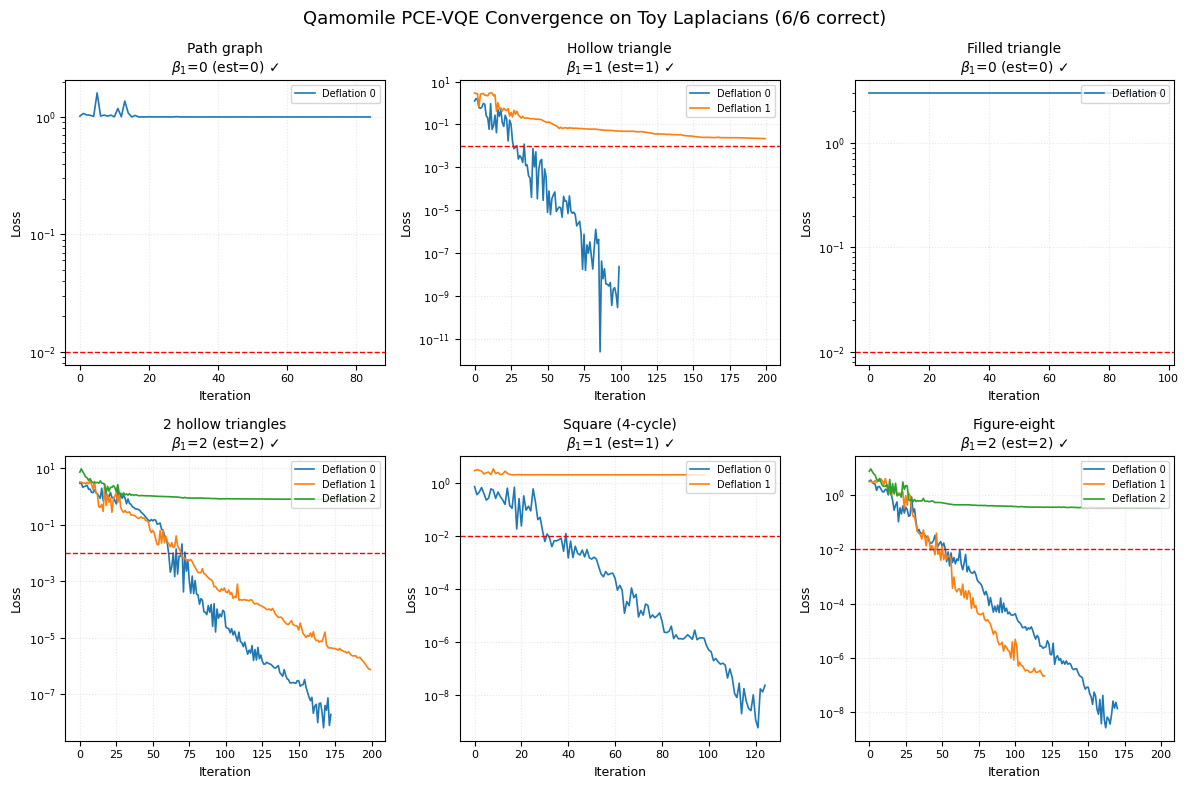

In [18]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, (name, (b_true, b_est, hists)) in zip(axes, results.items()):
    for r, h in enumerate(hists):
        if len(h) == 0:
            continue
        ax.semilogy(np.maximum(h, 1e-12), color=colors[r % len(colors)],
                    lw=1.2, label=f"Deflation {r}")
    ax.axhline(DELTA, color="red", ls="--", lw=1.0)
    mark = "✓" if b_true == b_est else "✗"
    ax.set_title(f"{name}\n" r"$\beta_1$=" f"{b_true} (est={b_est}) {mark}",
                 fontsize=10)
    ax.set_xlabel("Iteration", fontsize=9)
    ax.set_ylabel("Loss", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.3, ls=":")
    ax.tick_params(labelsize=8)

fig.suptitle(f"Qamomile PCE-VQE Convergence on Toy Laplacians "
             f"({n_ok}/{len(results)} correct)", fontsize=13, y=0.98)
fig.tight_layout()
plt.show()

各パネルは、各トイモデルにおける零空間ベクトルの探索の様子を示しています。
縦軸は損失関数の大きさ、横軸は反復回数です。
図中にある `Deflation` はデフレーションのラウンド数を表しています。
すなわち `Deflation 0` は最初の零空間ベクトルを探すラウンド、そして `Deflation 1` はその次の零空間ベクトルを探すラウンドです。
全てのパネルに存在する赤点線は閾値を表しており、損失関数の値がこれを下回ると、零空間ベクトルを発見したとみなします。  
`2 hollow triangles` の例 (左下パネル) を見てみましょう。
`Deflation 0, 1` では閾値を下回り、零空間ベクトルを発見できています。
しかし、`Deflation 2` は閾値を下回ることができずに最適化を終了しています。
2 つの零空間ベクトルが発見できていることから、この場合のベッチ数を $\beta_1 = 2$ と算出しています。

## まとめ

ここでは [Mazumder & Mazumder (2026)](https://arxiv.org/abs/2607.09906) で提案された qTDA アルゴリズムを、Qamomile で実装する方法をご紹介しました。
以下にこのページで紹介した重要な情報をまとめます。

* PCE をベッチ数推定に応用することで、少ない量子ビット数でこれを実現しました。ただし標準的な PCE とは異なり、$\pm 1$ の値ではなく連続変数のまま固有ベクトル成分として用いています。
* Qamomile により、簡単に VQE を実行することができます。
* ケース 1 の円周上の点群では、ウォームスタートによりベッチ数を正しく求めることに成功しました。
* またケース 2 の 6 つのトイモデルでは、変分デフレーションにより $\beta_1 = 0, 1, 2$ の複体の全てで正しく穴の数を数えることに成功しました。